# <center>Análise de Performance - Chess.com

### <center>Importação das Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import re

### <center> Requisição dos Dados

In [2]:
nome = "alguem465"  # Substitua pelo nome de usuário do Chess.com que deseja analisar
url = f"https://api.chess.com/pub/player/{nome}/games/archives"

headers = {
    "User-Agent": "ChessAnalyticsProject (Ubuntu 24.04; Projeto Pessoal; contato: wryelteodorodemorais3@gmail.com)"
}

resposta = requests.get(url, headers = headers)

if resposta.status_code != 200:
    print(f"Erro ao acessar a API: {resposta.status_code}")
    exit(1)
else:
    arquivos = resposta.json()["archives"]

### <center> Tratamento dos Dados

In [3]:
jogos = []

for arquivo_url in arquivos[-6:]: # Pegando os jogos dos últimos 6 meses
    resposta_jogos = requests.get(arquivo_url, headers = headers)
                
    if resposta_jogos.status_code == 200:
        jogos_mensais = resposta_jogos.json()["games"]

        for jogo in jogos_mensais:
            jogos.append(jogo)
    else:
        print(f"Erro ao acessar a API: {resposta_jogos.status_code}")
        exit(1)

jogos_processados = []

WIN_CODES = ["win"]
DRAW_CODES = ["agreed", "repetition", "stalemate", "insufficient", "50move", "timevsinsufficient"]
LOSE_CODES = ["lose", "checkmated", "timeout", "resigned", "abandoned"]

for jogo in jogos: # Processando cada jogo para extrair as informações relevantes
    if "white" in jogo and "black" in jogo:
        if jogo["white"]["username"].lower() == nome.lower():
            jogador_cor = "white"
            jogador = jogo["white"]
            adversario = jogo["black"]
        else:
            jogador_cor = "black"
            jogador = jogo["black"]
            adversario = jogo["white"]
        
        pgn = jogo.get("pgn", "")
        partida = re.search(r'\[ECOUrl "https://www.chess.com/openings/(.*?)"\]', pgn)
        
        if partida:
            abertura = partida.group(1)
            abertura = re.split(r'[0-9]+', abertura)[0]
            nome_abertura = abertura.replace('-', ' ')

        resultado = jogador.get("result")
        if resultado in WIN_CODES:
            resultado = "win"
        elif resultado in DRAW_CODES:
            resultado = "draw"
        elif resultado in LOSE_CODES:
            resultado = "lose"
        else:
            resultado = "desconhecido"   

        jogos_processados.append(
        {
        "data": pd.to_datetime(jogo["end_time"], unit = "s"),
        "rating": jogador.get("rating"),
        "resultado": resultado,
        "rating_adversario": adversario.get("rating"),
        "cor": jogador_cor,
        "abertura": nome_abertura if nome_abertura else "Desconhecida",
        "modo": jogo.get("time_class"),
        "ranqueado": jogo.get("rated")
        })

### <center> Informações Gerais

In [4]:
df = pd.DataFrame(jogos_processados)

vitorias = (df["resultado"] == "win").sum()
derrotas = (df["resultado"] == "lose").sum()
empates = (df["resultado"] == "draw").sum()

if df.empty:
    print("Nenhum jogo encontrado.")
    exit(1)
else:
    print("Nome do jogador:", nome)
    print("Total de jogos:", len(df))
    print("Total de vitórias:", vitorias)
    print("Total de derrotas:", derrotas)
    print("Total de empates:", empates)
    print("Rating atual:", df["rating"].iloc[-1])
    print("Maior rating alcançado:", df["rating"].max())
    print(f"Rating médio dos adversários: {int(df['rating_adversario'].mean())}")
    print("Abertura mais jogada:", df["abertura"].mode()[0])

Nome do jogador: alguem465
Total de jogos: 70
Total de vitórias: 40
Total de derrotas: 24
Total de empates: 6
Rating atual: 1506
Maior rating alcançado: 1506
Rating médio dos adversários: 1390
Abertura mais jogada: Kings Pawn Opening 


### <center> Taxa de Vitória

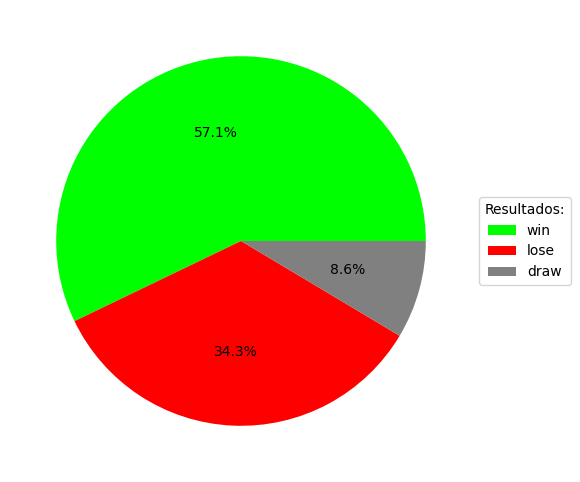

In [5]:
modos = ["win", "lose", "draw"]
quantidade = [vitorias, derrotas, empates]
cores = ["#00FF00", "#FF0000", "#808080"]

plt.figure(figsize = (6,6), facecolor = "none")  
plt.pie(quantidade, labels = None, autopct = "%1.1f%%", colors = cores) 
plt.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5)) 
plt.show()

### <center> Diferença entre Taxa de Vitórias (Pretas/Brancas)

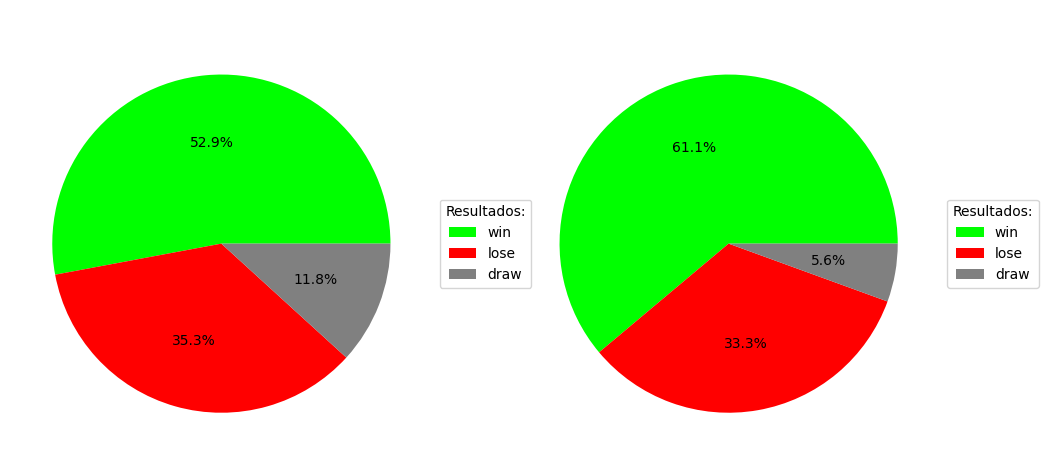

In [6]:
dados_brancas = df[df["cor"] == "white"]["resultado"].value_counts().reindex(modos, fill_value = 0)
dados_pretas = df[df["cor"] == "black"]["resultado"].value_counts().reindex(modos, fill_value = 0)

fig, (piz1, piz2) = plt.subplots(1, 2, figsize = (12,6), facecolor = "none")

# Gráfico para Brancas
piz1.pie(dados_brancas, labels = None, autopct = "%1.1f%%", colors = cores)
piz1.set_title("Taxa de Vitória - Brancas", color = "white")
piz1.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5)) 

# Gráfico para Pretas
piz2.pie(dados_pretas, labels = None, autopct = "%1.1f%%", colors = cores)
piz2.set_title("Taxa de Vitória - Pretas", color = "white")
piz2.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5))

plt.show()

### <center> Top 10 Aberturas Mais Usadas

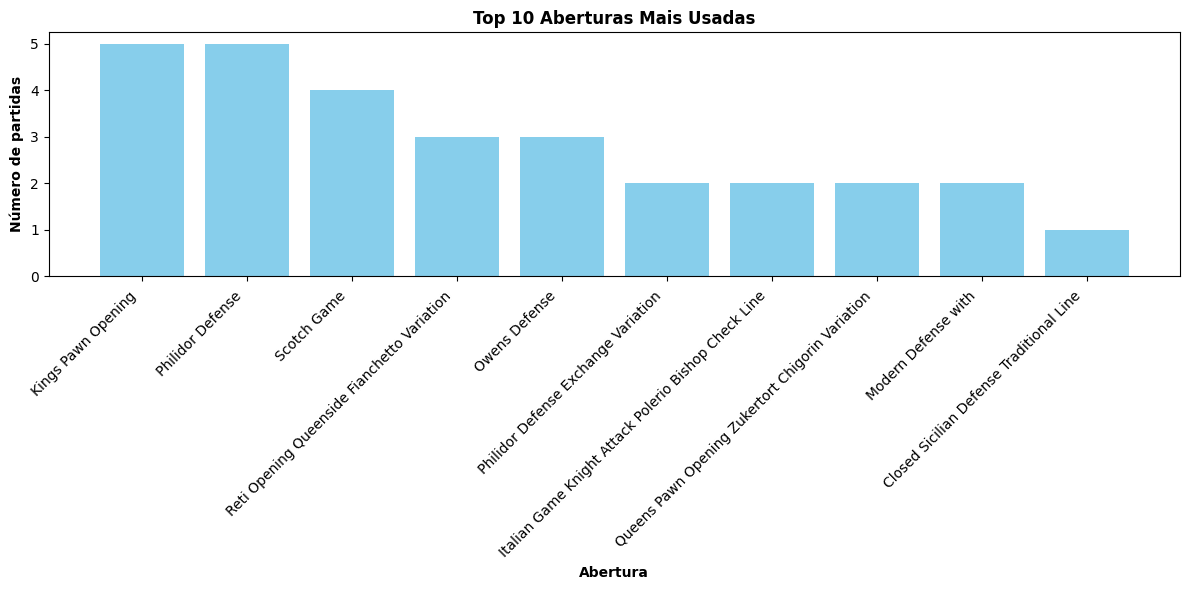

In [7]:
top_aberturas = df["abertura"].value_counts().head(10)

plt.figure(figsize = (12,6), facecolor= "none" )
plt.bar(top_aberturas.index, top_aberturas.values, color = "skyblue")

plt.xlabel("Abertura", fontweight = "bold")
plt.ylabel("Número de partidas", fontweight = "bold")
plt.title("Top 10 Aberturas Mais Usadas", fontweight = "bold")

plt.xticks(rotation = 45, ha = "right") 
plt.tight_layout() 
plt.show()

### <center> Evolução do Rating em Rápidas

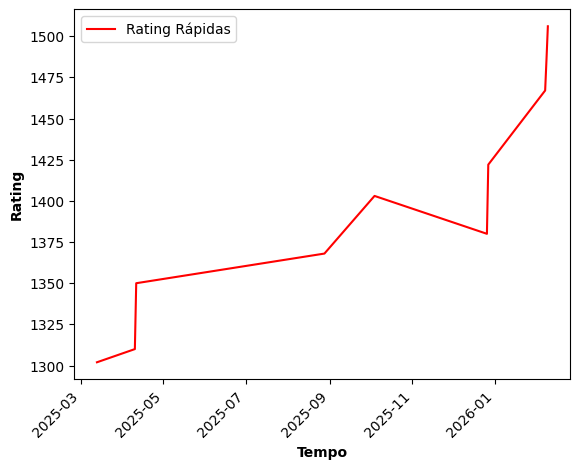

In [8]:
df_rapidas = df[(df["modo"] == "rapid") & df["ranqueado"]].sort_values(by = "data")

if df_rapidas.empty:
    print("Nenhum jogo de rápidas encontrado.")
else:
    df_rapidas_diario = df_rapidas.groupby(df_rapidas["data"].dt.date)["rating"].last().reset_index()
    df_rapidas_diario["data"] = pd.to_datetime(df_rapidas_diario["data"])  

    plt.figure(facecolor = "none")
    plt.plot(df_rapidas_diario["data"], df_rapidas_diario["rating"], linestyle = '-', color = "red", label = "Rating Rápidas")  

    plt.xlabel("Tempo", fontweight = "bold")
    plt.ylabel("Rating", fontweight = "bold")
    plt.legend()   
    plt.xticks(rotation = 45, ha = "right")  

    plt.show()

### <center> Rápidas: Diferença entre Taxa de Vitórias (Pretas/Brancas)

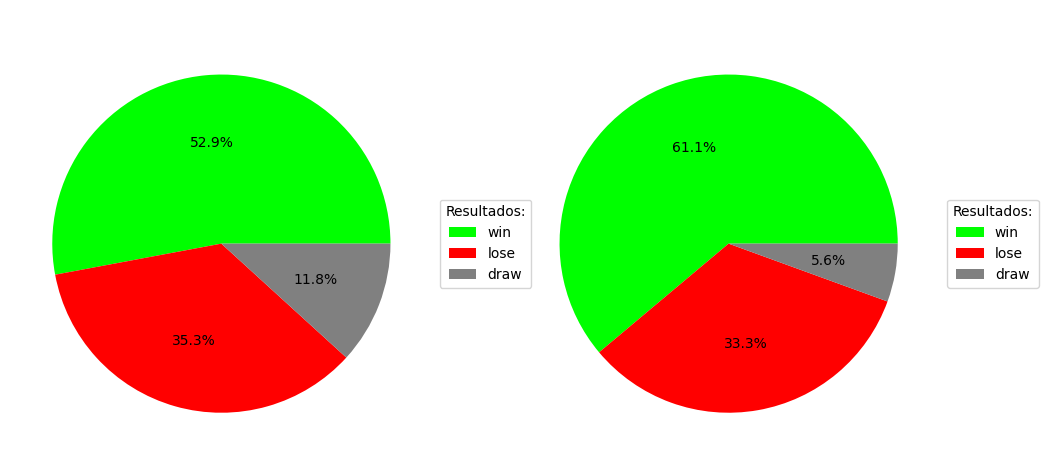

In [9]:
dados_brancas = df_rapidas[df_rapidas["cor"] == "white"]["resultado"].value_counts().reindex(modos, fill_value = 0)
dados_pretas = df_rapidas[df_rapidas["cor"] == "black"]["resultado"].value_counts().reindex(modos, fill_value = 0)

if dados_brancas.sum() == 0 or dados_pretas.sum() == 0:
    print("Não há dados suficientes para criar os gráficos de pizza para Brancas ou Pretas")
else:
    fig, (piz1, piz2) = plt.subplots(1, 2, figsize = (12,6), facecolor = "none")

    # Gráfico para Brancas
    piz1.pie(dados_brancas, labels = None, autopct = "%1.1f%%", colors = cores)
    piz1.set_title("Taxa de Vitória - Brancas", color = "white")
    piz1.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5)) 

    # Gráfico para Pretas
    piz2.pie(dados_pretas, labels = None, autopct = "%1.1f%%", colors = cores)
    piz2.set_title("Taxa de Vitória - Pretas", color = "white")
    piz2.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5))

    plt.show()

### <center> Evolução do Rating em Blitz

In [10]:
df_blitz  = df[(df["modo"] == "blitz") & df["ranqueado"]].sort_values(by = "data")

if df_blitz.empty:
    print("Nenhum jogo de blitz encontrado.")
else:
    df_blitz_diario = df_blitz.groupby(df_blitz["data"].dt.date)["rating"].last().reset_index()
    df_blitz_diario["data"] = pd.to_datetime(df_blitz_diario["data"])  

    plt.figure(facecolor = "none")
    plt.plot(df_blitz_diario["data"], df_blitz_diario["rating"], linestyle = '-', color = "blue", label = "Rating Blitz")  

    plt.xlabel("Tempo", fontweight = "bold")
    plt.ylabel("Rating", fontweight = "bold")
    plt.legend()    
    plt.xticks(rotation = 45, ha = "right")

    plt.show()

Nenhum jogo de blitz encontrado.


### <center> Blitz: Diferença entre Taxa de Vitórias (Pretas/Brancas)

In [11]:
dados_brancas = df_blitz[df_blitz["cor"] == "white"]["resultado"].value_counts().reindex(modos, fill_value = 0)
dados_pretas = df_blitz[df_blitz["cor"] == "black"]["resultado"].value_counts().reindex(modos, fill_value = 0)

if dados_brancas.sum() == 0 or dados_pretas.sum() == 0:
    print("Não há dados suficientes para criar os gráficos de pizza para Brancas ou Pretas.")
else:   
    fig, (piz1, piz2) = plt.subplots(1, 2, figsize = (12,6), facecolor = "none")

    # Gráfico para Brancas
    piz1.pie(dados_brancas, labels = None, autopct = "%1.1f%%", colors = cores)
    piz1.set_title("Taxa de Vitória - Brancas", color = "white")
    piz1.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5)) 

        # Gráfico para Pretas
    piz2.pie(dados_pretas, labels = None, autopct = "%1.1f%%", colors = cores)
    piz2.set_title("Taxa de Vitória - Pretas", color = "white")
    piz2.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5))

    plt.show()

Não há dados suficientes para criar os gráficos de pizza para Brancas ou Pretas.


### <center> Evolução do rating em Bullet

In [12]:
df_bullet  = df[(df["modo"] == "bullet") & df["ranqueado"]].sort_values(by = "data")

if df_bullet.empty:
    print("Nenhum jogo de bullet encontrado.")
else:
    df_bullet_diario = df_bullet.groupby(df_bullet["data"].dt.date)["rating"].last().reset_index()
    df_bullet_diario["data"] = pd.to_datetime(df_bullet_diario["data"])  
    
    plt.figure(facecolor = "none")
    plt.plot(df_bullet_diario["data"], df_bullet_diario["rating"], linestyle = '-', color = "green", label = "Rating Bullet")  

    plt.xlabel("Tempo", fontweight = "bold")
    plt.ylabel("Rating", fontweight = "bold")
    plt.legend()   
    plt.xticks(rotation = 45, ha = "right") 

    plt.show()

Nenhum jogo de bullet encontrado.


### <center> Bullet: Diferença entre Taxa de Vitórias (Pretas/Brancas)

In [13]:
dados_brancas = df_bullet[df_bullet["cor"] == "white"]["resultado"].value_counts().reindex(modos, fill_value = 0)
dados_pretas = df_bullet[df_bullet["cor"] == "black"]["resultado"].value_counts().reindex(modos, fill_value = 0)

if dados_brancas.sum() == 0 or dados_pretas.sum() == 0:
    print("Não há dados suficientes para criar os gráficos de pizza para Brancas ou Pretas.")
else:
    fig, (piz1, piz2) = plt.subplots(1, 2, figsize = (12,6), facecolor = "none")

    # Gráfico para Brancas
    piz1.pie(dados_brancas, labels = None, autopct = "%1.1f%%", colors = cores)
    piz1.set_title("Taxa de Vitória - Brancas", color = "white")
    piz1.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5)) 

    # Gráfico para Pretas
    piz2.pie(dados_pretas, labels = None, autopct = "%1.1f%%", colors = cores)
    piz2.set_title("Taxa de Vitória - Pretas", color = "white")
    piz2.legend(modos, title = "Resultados:", loc = "center left", bbox_to_anchor = (1, 0.5))

plt.show()

Não há dados suficientes para criar os gráficos de pizza para Brancas ou Pretas.
